# Evaluate impact of population on stochastic evolution of a colony of B cells

In [1]:
import matplotlib.pyplot as plt
from __future__ import annotations
import numpy as np
from numpy.random import default_rng
import pandas as pd
from collections import defaultdict
import matplotlib.ticker as mtick


In [2]:
"""
Germinal‑centre B‑cell maturation with multiple antigens
========================================================

• State of each cycling B‑cell: h ∈ ℝ^{N_h} (residue binding‑energy vector)
• Antigens:            S_mat ∈ {‑1, +1}^{N_h × n_A}
                       ε_v(h) = Σ_i s_{iv} h_i    for every antigen v
• One round:           duplication → SHM → Ag‑gate → T‑gate → differentiation
• Output:              `history[step]` is a NumPy array of shape
                       (n_cells_alive_that_step, N_h) with the h‑vectors

The implementation below follows exactly the gates used in your FP solver.
"""



mu=0.001*3*40
p_sil=0.5*(mu)+(1-mu)
p_let=0.3*(mu)
p_aa=0.2*(mu)
E_a=np.log(40)                       
T=140
T_steps = 140

kBT=1                       # thermal factor
N_i=2500  
N_max=2500 
mu_i=0.0 
sigma_i=0.001 

p_diff=0.10
c=170# 800, 1120, 920, 510

# global parameters (use existing values or define defaults)

# -------------------------- helper functions ---------------------------
def energies(pop: np.ndarray, S_mat: np.ndarray) -> np.ndarray:
    """
    Compute energies for every cell and every antigen.

    Parameters
    ----------
    pop   : (N_cells, N_h) ndarray
    S_mat : (N_h, n_A)     ndarray

    Returns
    -------
    eps : (N_cells, n_A) ndarray   with eps[c, v] = ε_v(h_c)
    """
    return pop @ S_mat                     # broadcasting handles dot‑product

def P_Ag(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    Antigen‑binding survival gate   P_Ag(h)

    eps   : (N_cells, n_A) energies
    C_vec : (n_A,)        antigen concentrations at current round
    """
    exp_term   = np.exp((eps - E_a) / kBT)         # same as FP code
    numer      = (exp_term * C_vec).sum(axis=1)    # Σ_v C_v e^{(ε_v - E_a)/kT}
    return numer / (1.0 + numer)

def P_T(eps: np.ndarray, C_vec: np.ndarray) -> np.ndarray:
    """
    T‑cell‑help survival gate   P_T(h | pop)

    eps   : (N_cells, n_A) energies *after* Ag selection
    """
    C_tot      = C_vec.sum()
    eE         = np.exp(eps / kBT)                 # e^{ε_v/kT}
    Phi        = (eE * C_vec).sum(axis=1)          # Σ_v C_v e^{ε_v/kT}
    Phi_bar    = Phi.mean()                       # ⟨Φ⟩_pop
    return Phi / (Phi + Phi_bar / C_tot)

# --

In [3]:
def gc_round(pop: np.ndarray,
             S_mat: np.ndarray,
             C_vec: np.ndarray,
             rng: np.random.Generator,
             mu_M: np.ndarray,
             sigma_M: np.ndarray,
             mutable_positions=None,
             uniq_counts: np.ndarray | None = None,        # NEW: unique mutated sites per cell
             mut_sites: np.ndarray | None = None           # NEW: boolean mask (n_cells, N_h)
             ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns:
        pop_next   : GC survivors after differentiation (n_t, N_h)
        mem_cells  : differentiated cells (n_mem, N_h)
        parent_idx : parent row index in previous gen (n_t,)
        uniq_counts: unique mutated-site counts aligned to pop_next (n_t,)
        mut_sites  : boolean mutated-sites mask aligned to pop_next (n_t, N_h)
    Counting rule: only the first mutation at a site counts for that lineage; repeated hits to the same site do not.
    """
    N_h = pop.shape[1]
    assert mu_M.shape == (N_h,) and sigma_M.shape == (N_h,), "mu_M and sigma_M must be length N_h"

    # init counters/masks for gen-0
    if uniq_counts is None:
        uniq_counts = np.zeros(pop.shape[0], dtype=int)
    if mut_sites is None:
        mut_sites = np.zeros((pop.shape[0], N_h), dtype=bool)

    # 1) Duplication: replicate state, counts, and masks; track parents
    prev_n = pop.shape[0]
    pop        = np.repeat(pop,        2, axis=0)
    uniq_counts = np.repeat(uniq_counts, 2, axis=0)
    mut_sites  = np.repeat(mut_sites,  2, axis=0)
    parent_idx = np.repeat(np.arange(prev_n, dtype=int), 2)


    # 2) SHM: at most one site per mutating cell this round
    N_cells = pop.shape[0]
    fate = rng.choice(["let", "aa", "sil"], size=N_cells, p=[p_let, p_aa, p_sil])
    alive_mask = fate != "let"
    aa_mask    = fate == "aa"

    if aa_mask.any():
        rows = np.flatnonzero(aa_mask)
        if mutable_positions is None:
            idx_sites = rng.integers(0, N_h, size=rows.size)
        else:
            mp = np.asarray(mutable_positions, dtype=int)
            idx_sites = rng.choice(mp, size=rows.size)
        delta_h = rng.normal(mu_M[idx_sites], sigma_M[idx_sites])
        # apply mutation to h
        # pop[rows, idx_sites] = np.clip(pop[rows, idx_sites] + delta_h, -3*np.log(10), 1*np.log(10))
        pop[rows, idx_sites] = pop[rows, idx_sites] + delta_h
        # UNIQUE-SITE counting: only first hit to a site increments
        # (relative to this lineage's gen-0 founder; we encode that by the boolean mut_sites)
        for r, i in zip(rows, idx_sites):
            if not mut_sites[r, i]:
                uniq_counts[r] += 1
                mut_sites[r, i] = True

    # lethal removal
    pop        = pop[alive_mask]
    parent_idx = parent_idx[alive_mask]
    uniq_counts = uniq_counts[alive_mask]
    mut_sites  = mut_sites[alive_mask]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 3) Antigen-binding gate (shape-safe reduction over possible multi-C_vec outputs)
    eps  = energies(pop, S_mat)
    P_ag = P_Ag(eps, C_vec)
    if isinstance(P_ag, np.ndarray) and P_ag.ndim == 2:
        P_ag = P_ag.max(axis=1)  # or .mean/.min per your policy
    P_ag = np.asarray(P_ag, dtype=float).reshape(-1)
    assert P_ag.shape[0] == pop.shape[0]
    survive = rng.random(pop.shape[0]) < P_ag

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 4) T-cell-help gate (shape-safe)
    P_t = P_T(eps, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.shape[0] != pop.shape[0]:
        eps_t = energies(pop, S_mat)
        P_t = P_T(eps_t, C_vec)
    if isinstance(P_t, np.ndarray) and P_t.ndim == 2:
        P_t = P_t.max(axis=1)
    P_t = np.asarray(P_t, dtype=float).reshape(-1)
    if P_t.shape[0] != pop.shape[0]:
        if P_t.size == 1:
            P_t = np.full(pop.shape[0], float(P_t))
        else:
            raise ValueError(f"P_T shape {P_t.shape} must match n_cells {pop.shape[0]}")
    survive = rng.random(pop.shape[0]) < P_t

    pop        = pop[survive]
    parent_idx = parent_idx[survive]
    uniq_counts = uniq_counts[survive]
    mut_sites  = mut_sites[survive]
    if pop.size == 0:
        return pop, np.empty((0, N_h)), np.empty((0,), dtype=int), np.empty((0,), dtype=int), np.empty((0, N_h), dtype=bool)

    # 5) Differentiation
    diff_mask  = rng.random(size=pop.shape[0]) < p_diff
    mem_cells  = pop[diff_mask]
    keep_mask  = ~diff_mask
    pop        = pop[keep_mask]
    parent_idx = parent_idx[keep_mask]
    uniq_counts = uniq_counts[keep_mask]
    mut_sites  = mut_sites[keep_mask]

    return pop, mem_cells, parent_idx, uniq_counts, mut_sites


In [4]:
def plot_h_dimension(history, dim_idx=0, h_min=-4, h_max=10, n_hbins=100, t_clip=50, cmap="Greys_r"):
    """
    Plot the density of B-cell h[dim_idx] values over rounds with fixed colorbar scale [0, 500].
    """
    time_points = []
    h_values = []
    for t, pop in enumerate(history):
        if pop.size == 0:
            continue
        time_points.extend([t] * pop.shape[0])
        h_values.extend(pop[:, dim_idx])

    rounds_arr = np.asarray(time_points)
    h_vals     = np.asarray(h_values)

    n_rounds   = len(history)
    round_bins = np.linspace(rounds_arr.min(), rounds_arr.max(), n_rounds + 1)
    h_bins     = np.linspace(h_min, h_max, n_hbins + 1)

    H, xedges, yedges = np.histogram2d(rounds_arr, h_vals, bins=[round_bins, h_bins])

    plt.figure(figsize=(8, 5))
    im = plt.imshow(H.T, origin="lower", aspect="auto",
                    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     vmin=0.0, vmax=100)  # fixed scale
    plt.xlabel("Round")
    plt.ylabel(rf"$h_{{{dim_idx+1}}}$")
    plt.title(rf"Density of B-cells in $h_{{{dim_idx+1}}}$ over GC rounds")
    plt.colorbar(im, label="Density")
    plt.ylim(h_min, h_max)
    plt.tight_layout()
    plt.show()

In [5]:
import numpy as np
from numpy.random import default_rng

def simulate_gc_with_ancestry(rounds: int,
                              S_mat: np.ndarray,
                              N_init: int,
                              N_max: int,
                              C_schedule,
                              mu_init: float = mu_i,   # Update with your default mu_i if needed
                              sigma_init: float = sigma_i, # Update with your default sigma_i if needed
                              mu_M: np.ndarray | None = None,
                              sigma_M: np.ndarray | None = None,
                              mutable_positions=None,
                              seed: int | None = None
                              ) -> list[dict]:
    """
    Simulates GC evolution and tracks ancestry using global unique IDs.
    
    Returns:
        history : list of dicts per generation (t=0..T). Keys:
                  'ids': global unique cell IDs
                  'parent_ids': global IDs of the parents (-1 for root)
                  'pop': cell states (N, N_h)
                  'uniq_counts': unique mutated-site count aligned to pop
    """
    rng = default_rng(seed)
    N_h = S_mat.shape[0]
    if mu_M is None or sigma_M is None:
        raise ValueError("Provide per-site mu_M and sigma_M of shape (N_h,)")

    pop = rng.normal(mu_init, sigma_init, size=(N_init, N_h))
    if mutable_positions is not None:
        mutable_positions = np.array(mutable_positions, dtype=int)
        all_positions = np.arange(N_h)
        non_mutable_positions = np.setdiff1d(all_positions, mutable_positions)
        pop[:, non_mutable_positions] = 0.0

    # Initialize ID tracking
    next_id = N_init
    initial_ids = np.arange(N_init, dtype=int)
    initial_parent_ids = np.full(N_init, -1, dtype=int)

    # Setup history as list of dicts
    uniq_counts = np.zeros(pop.shape[0], dtype=int)
    mut_sites = np.zeros((pop.shape[0], N_h), dtype=bool)

    history = [{
        'ids': initial_ids,
        'parent_ids': initial_parent_ids,
        'pop': pop.copy(),
        'uniq_counts': uniq_counts.copy()
    }]

    for r in range(rounds):
        C_vec = np.asarray(C_schedule(r), dtype=float)
        
        # Run GC round
        pop_next, _mem, parent_idx, uniq_counts, mut_sites = gc_round(
            pop, S_mat, C_vec, rng, mu_M, sigma_M,
            mutable_positions=mutable_positions,
            uniq_counts=uniq_counts, mut_sites=mut_sites
        )

        # Apply capacity cap consistently
        if pop_next.shape[0] > N_max:
            keep_idx   = rng.choice(pop_next.shape[0], N_max, replace=False)
            pop_next   = pop_next[keep_idx]
            parent_idx = parent_idx[keep_idx]
            uniq_counts = uniq_counts[keep_idx]
            mut_sites   = mut_sites[keep_idx]

        # Map row indices to actual global parent IDs from the previous frame
        prev_ids = history[-1]['ids']
        current_parent_ids = prev_ids[parent_idx]

        # Assign new global IDs to the survivors
        n_survivors = pop_next.shape[0]
        current_ids = np.arange(next_id, next_id + n_survivors, dtype=int)
        next_id += n_survivors

        # Store generation data
        history.append({
            'ids': current_ids,
            'parent_ids': current_parent_ids,
            'pop': pop_next.copy(),
            'uniq_counts': uniq_counts.copy()
        })
        
        pop = pop_next

    return history

In [6]:
df = pd.read_csv('../data_mat/final_variant_scores.csv')

# Use the .isin() method for filtering rows based on a list of values
allowed_annotations = ['CDRH1', 'CDRH2', 'CDRH3', 'CDRL1', 'CDRL2', 'CDRL3']
df = df[df['annotation'].isin(allowed_annotations)]
df['annotation'].unique()

print(df["delta_bind_CGG"].mean() * np.log(10))

print(df["delta_bind_CGG"].std()* np.log(10))


-1.031567993994919
1.7515742333362647


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Group by position, take the first wildtype amino acid for each position
wt_seq = (
    df.groupby("position")["wildtype"]
      .first()
      .sort_index()
      .str.cat()
)
print('len',len(wt_seq))

print(wt_seq)

df = df[df["single_nt"].apply(lambda x: isinstance(x, bool))]
df = df[df["single_nt"]]  # keep only single-nt rows
df['position'] = df['position'] - 1

print(df["delta_bind_CGG"].mean() * np.log(10))

print(df["delta_bind_CGG"].std()* np.log(10))

# Group and compute mean/std
stats = df.groupby(["position", "annotation"])["delta_bind_CGG"].agg(["mean", "std"]).reset_index()

# Arrays (ordered by position)
positions = stats["position"].to_numpy()
mu_arr = stats["mean"].to_numpy() * np.log(10)
sigma_arr = stats["std"].to_numpy() * np.log(10)

print(len(positions))
print(mu_arr)
print(sigma_arr)
print(mu_arr.mean())





len 40
GDSITSGYYISYSGSTARDFDVQNVGTNSASQQYNSYPLT
-0.7913685301950631
1.6864998765917716
40
[ 0.22103172  1.26389759  0.16960184 -0.71205141 -0.30731452 -0.0529463
 -1.51018662 -3.14495296 -1.98401587  0.09835657 -0.52276576 -0.26164932
 -0.73205759 -0.26663277  0.19565394  0.25604362 -1.31664118 -3.35076788
 -2.18586993 -0.46051044 -1.0071536  -0.33069069  0.2339887   0.06324913
 -0.7381397  -0.74947829 -0.41773883 -1.21797829 -1.58449323 -0.40320568
 -0.49252295 -0.98764125 -1.55631726 -3.4382398   0.94925222  0.30822404
 -3.07005644 -1.47618401 -0.7327681  -0.6213164 ]
[0.5331775  0.74049486 0.19864102 0.91713086 0.78067121 0.1466031
 1.1957676  2.79081499 1.91297848 0.22728794 0.72413258 0.71696882
 2.14744907 0.44998865 0.84405372 0.20062656 2.00137303 2.26438893
 1.67674228 0.92123678 1.2942475  0.58379482 0.61148675 0.201573
 1.30095802 0.89456854 0.57941635 1.73745639 2.42484008 1.23658201
 1.31855134 1.95551488 1.42024837 2.30692581 1.14894814 0.70163801
 2.07314568 0.91044491 2

# Keep normal distrib


In [9]:
positions

array([ 25,  26,  27,  28,  29,  30,  31,  32,  49,  50,  51,  52,  53,
        54,  55,  56,  95,  96,  97,  98,  99, 100, 153, 154, 155, 156,
       157, 158, 176, 177, 178, 215, 216, 217, 218, 219, 220, 221, 222,
       223], dtype=int64)

In [10]:
print(df.annotation.unique())
# Keep only unique (position, annotation) pairs
pos_annotation_dict = (
    df.drop_duplicates(subset=["position", "annotation"])
      .set_index("position")["annotation"]
      .to_dict()
)

print(pos_annotation_dict)
cdr_positions = (
    df[df["annotation"].str.contains("CDR", na=False)]
    .drop_duplicates(subset=["position"])
    [["position"]]
    .to_records(index=False)
    .tolist()
)
cdr_positions=[pos[0] for pos in cdr_positions]
print(cdr_positions)#absolute position
#i need index of cdr_positions inside position array
cdr_positions_relative = [np.where(positions == p)[0][0] for p in cdr_positions]

print(cdr_positions_relative)

['CDRH1' 'CDRH2' 'CDRH3' 'CDRL1' 'CDRL2' 'CDRL3']
{25: 'CDRH1', 26: 'CDRH1', 27: 'CDRH1', 28: 'CDRH1', 29: 'CDRH1', 30: 'CDRH1', 31: 'CDRH1', 32: 'CDRH1', 49: 'CDRH2', 50: 'CDRH2', 51: 'CDRH2', 52: 'CDRH2', 53: 'CDRH2', 54: 'CDRH2', 55: 'CDRH2', 56: 'CDRH2', 95: 'CDRH3', 96: 'CDRH3', 97: 'CDRH3', 98: 'CDRH3', 99: 'CDRH3', 100: 'CDRH3', 153: 'CDRL1', 154: 'CDRL1', 155: 'CDRL1', 156: 'CDRL1', 157: 'CDRL1', 158: 'CDRL1', 176: 'CDRL2', 177: 'CDRL2', 178: 'CDRL2', 215: 'CDRL3', 216: 'CDRL3', 217: 'CDRL3', 218: 'CDRL3', 219: 'CDRL3', 220: 'CDRL3', 221: 'CDRL3', 222: 'CDRL3', 223: 'CDRL3'}
[25, 26, 27, 28, 29, 30, 31, 32, 49, 50, 51, 52, 53, 54, 55, 56, 95, 96, 97, 98, 99, 100, 153, 154, 155, 156, 157, 158, 176, 177, 178, 215, 216, 217, 218, 219, 220, 221, 222, 223]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]


In [11]:
len(mu_arr)

40

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load and Process Experimental Data (from original code, unchanged) ---
# NOTE: Assume 'simulate_gc_history', T, S_mat, N_i, N_max, C_schedule, mu_arr,
# sigma_arr, and cdr_positions_relative are defined elsewhere in the context.
S_mat = np.array([[1] for pos in range (len(positions))])

N_h   = S_mat.shape[0]
print('Nh', N_h)
# Antigen concentration (constant here)
c=170
def C_schedule(r):
    return np.array([c])

Nh 40


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------- Mean Affinity vs FP Comparison ----------------------
N_max_array = [500, 2500, 5000]
c_array = [100, 200, 500]
colors = ['navy', 'darkorange', 'forestgreen']  # Colors for different N_max
n_seeds = 50  # Number of stochastic runs per configuration

# Dictionary to store results for each N_max
results = {}
dead_c_info = []

for N_max, color in zip(N_max_array, colors):
    print(f"\n--- Running for N_max={N_max} ---")
    
    # Initialize storage for this specific N_max
    results[N_max] = {
        'stoch_means': [], 'stoch_stds': [],
        'fp_means': [], 'fp_stds': [],
        'valid_c': [], 'color': color
    }
    
    for c in c_array:
        def C_schedule(r): return np.array([c])
        
        print(f"Simulating for c={c} across {n_seeds} seeds...")
        seed_means = []
        
        # Run Simulation across multiple seeds
        for seed in range(1, n_seeds + 1):
            history = simulate_gc_with_ancestry(
                rounds=T,                
                S_mat=S_mat,
                N_init=N_max,            
                N_max=N_max,             
                C_schedule=C_schedule,   
                mu_M=mu_arr,             
                sigma_M=sigma_arr,       
                mutable_positions=cdr_positions_relative, 
                seed=seed              
            )
            
            # 1. Extract the final state from history
            final_frame = history[-1]
            final_pop = final_frame['pop']

            # 2. Calculate total affinities for the final population
            final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
            
            # Only record the mean if the population survived this specific seed
            if len(final_affinities) > 0:
                seed_means.append(final_affinities.mean())
                
        print(f"Surviving runs for N_max={N_max}, c={c}: {len(seed_means)}/{n_seeds}")

        # Load the csv of results from fokker planck
        fp_filename = f'../multi Ag/rho_epsilon_last_step_N_max={N_max}_c={c}.csv'
        try:
            df_fp = pd.read_csv(fp_filename)
            eps_fp = df_fp['epsilon'].values
            rho_fp = df_fp['rho_epsilon'].values
        except FileNotFoundError:
            eps_fp, rho_fp = np.array([]), np.array([])

        # 3. Check for dead populations
        # Stochastic is considered dead if ALL seeds died
        stoch_dead = len(seed_means) == 0
        fp_dead = len(rho_fp) == 0 or not np.sum(rho_fp) > 1 

        if stoch_dead or fp_dead:
            if stoch_dead and fp_dead:
                status = "Dead"
            elif stoch_dead:
                status = "Stoch Dead"
            else:
                status = "FP Dead"
            
            dead_c_info.append(f"N_max={N_max}, c={c}: {status}")
            continue  # Skip plotting points for dead populations

        # 4. Calculate Stochastic Moments ACROSS SEEDS
        results[N_max]['stoch_means'].append(np.mean(seed_means))
        results[N_max]['stoch_stds'].append(np.std(seed_means))

        # 5. Calculate Fokker-Planck Moments
        total_mass = np.sum(rho_fp)
        mean_fp = np.sum(eps_fp * rho_fp) / total_mass
        
        # Variance = E[X^2] - (E[X])^2
        var_fp = np.sum((eps_fp**2) * rho_fp) / total_mass - (mean_fp**2)
        # Ensure no negative variance due to floating point inaccuracies
        std_fp = np.sqrt(max(0, var_fp)) 

        results[N_max]['fp_means'].append(mean_fp)
        results[N_max]['fp_stds'].append(std_fp)
        results[N_max]['valid_c'].append(c)




--- Running for N_max=500 ---
Simulating for c=100 across 50 seeds...
Surviving runs for N_max=500, c=100: 50/50
Simulating for c=200 across 50 seeds...
Surviving runs for N_max=500, c=200: 50/50
Simulating for c=500 across 50 seeds...
Surviving runs for N_max=500, c=500: 50/50

--- Running for N_max=2500 ---
Simulating for c=100 across 50 seeds...
Surviving runs for N_max=2500, c=100: 50/50
Simulating for c=200 across 50 seeds...
Surviving runs for N_max=2500, c=200: 50/50
Simulating for c=500 across 50 seeds...
Surviving runs for N_max=2500, c=500: 50/50

--- Running for N_max=5000 ---
Simulating for c=100 across 50 seeds...
Surviving runs for N_max=5000, c=100: 50/50
Simulating for c=200 across 50 seeds...
Surviving runs for N_max=5000, c=200: 50/50
Simulating for c=500 across 50 seeds...
Surviving runs for N_max=5000, c=500: 50/50


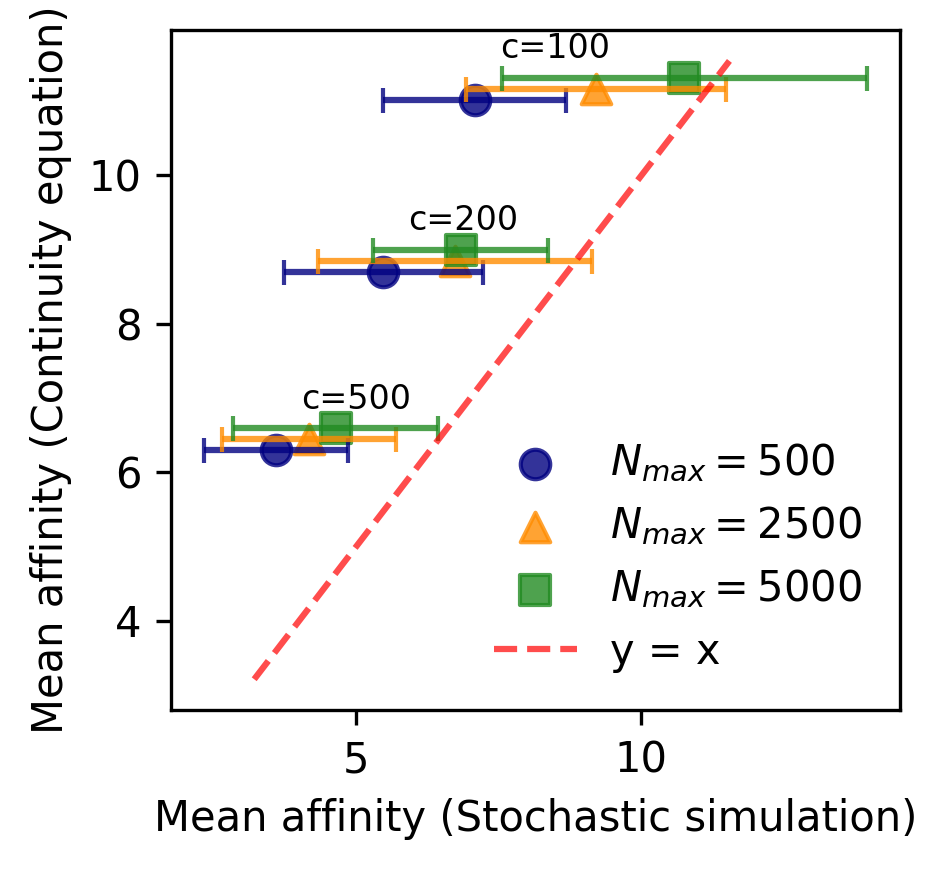

In [21]:
# ---------------------- Plotting ----------------------
plt.figure(figsize=(3.2, 3.), dpi=300)

global_min = float('inf')
global_max = float('-inf')

# Flag to ensure we only label the concentrations once
annotated_c = False

# Define different markers for each N_max (circle, triangle, square)
markers = ['o', '^', 's']

# Set a small base offset for the y-axis to prevent overlap.
# Adjust this value depending on the scale of your y-axis!
jitter_amount = 0.15 

# Iterate through the stored results to plot each N_max
for idx, N_max in enumerate(N_max_array):
    res = results[N_max]
    
    if not res['valid_c']:
        continue
        
    # Calculate a slight vertical shift based on the loop index.
    # This dynamically centers the shifts (e.g., -offset, 0, +offset for 3 items).
    offset = (idx - (len(N_max_array) - 1) / 2.0) * jitter_amount
    
    # Apply the shift to the y-coordinates
    shifted_y = [y + offset for y in res['fp_means']]
        
    # Scatter plot using the shifted y-coordinates
    plt.scatter(
        res['stoch_means'], shifted_y, 
        marker=markers[idx % len(markers)], 
        color=res['color'], 
        label=f'$N_{{max}}={N_max}$', 
        alpha=0.8,
        s=50  # Size of the marker
    )
    
    # Error bars applied using the shifted y-coordinates
    plt.errorbar(
        res['stoch_means'], shifted_y,
        xerr=res['stoch_stds'],
        fmt='none',           
        ecolor=res['color'],  
        alpha=0.8,
        capsize=3             
    )
    
    # Annotate each point with its concentration ONLY ONCE, in black
    if not annotated_c:
        for i, c in enumerate(res['valid_c']):
            plt.annotate(
                f"c={c}", 
                (res['stoch_means'][i], shifted_y[i]), 
                textcoords="offset points", 
                xytext=(6, 10), 
                ha='left', 
                fontsize=8,
                color='black'
            )
        annotated_c = True  # Prevent future iterations from adding text

    # Track global bounds using the ORIGINAL unshifted data 
    # to properly scale the y=x reference line
    current_min = min(min(res['stoch_means']), min(res['fp_means']))
    current_max = max(max(res['stoch_means']), max(res['fp_means']))
    global_min = min(global_min, current_min)
    global_max = max(global_max, current_max)

# Add reference line y = x to show perfect agreement
if global_min != float('inf'):
    # Add a slight padding to the bounds for the reference line so it stretches past the points
    padding = (global_max - global_min) * 0.05
    plt.plot([global_min - padding, global_max + padding], 
             [global_min - padding, global_max + padding], 
             'r--', lw=1.5, label='y = x', alpha=0.7)

# If any populations died, list them in a text box on the graph
if dead_c_info:
    # Join multiple dead population warnings with a newline
    text_str = "\n".join(dead_c_info)
    plt.gca().text(
        0.05, 0.95, text_str, # Placed on the left to avoid the legend
        transform=plt.gca().transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='red', alpha=0.7)
    )

plt.xlabel("Mean affinity (Stochastic simulation)")
plt.ylabel("Mean affinity (Continuity equation)")
# plt.title("Affinity Comparison (Stochastic vs FP)")

plt.legend(frameon=False, loc='lower right')
# plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()